In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import CFG, PATHS
from src.data import load_data, undersampling
from src.features import compute_rdkit_descriptors, compute_smited_embeddings
from src.models import build_rf, build_nn, run_experiment
from src.metrics import compute_ccr

In [6]:
#Load data
smiles_col = CFG["data"]["smiles_col"]
activity_col = CFG["data"]["activity_col"]

train_df, test_df = load_data (PATHS["train"], PATHS["test"])

print(f"Train: {len(train_df)} compounds ({train_df[activity_col].sum()} active)")
print(f"Test:  {len(test_df)} compounds ({test_df[activity_col].sum()} active)")
train_df.head(3)

Train: 1348 compounds (54 active)
Test:  175 compounds (30 active)


,SMILES,NSC#,"Activity (1 = active, 0 = inactive)",Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,C1CC2(CCC13NC4=CC=CC5=C4C(=CC=C5)N3)NC6=CC=CC7...,NSC97920,0,NaN,NaN,NaN,NaN
1,C1=CC2=C(C=CC=C2[As](=O)(O)O)C(=C1)N,NSC13785,0,NaN,NaN,NaN,NaN
2,C1=CC2(C3C1C(OC(=C3)C(=O)N)OC2=O)O,NSC357683,0,NaN,NaN,NaN,NaN


In [7]:
#Undersampling
subsets = undersampling(
    train_df,
    activity_col,
    n_splits=19,
    seed=42
)

print(f"Number of subsets: {len(subsets)}")
print(f"Sizes: {[len(s) for s in subsets]}")
print(f"Active compounds in subset 0: {(subsets[0][activity_col] == 1).sum()}")

Number of subsets: 19
Sizes: [123, 123, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122, 122]
Active compounds in subset 0: 54


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [8]:
#RDKit feature 

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

all_train_smiles = train_df[smiles_col].tolist()
_, global_mask = compute_rdkit_descriptors(all_train_smiles)

test_smiles = test_df[smiles_col].tolist()
test_y = test_df[activity_col].tolist()
test_X_rdkit, _ = compute_rdkit_descriptors(test_smiles, nan_mask=global_mask)

def rdkit_fn(subset):
    smiles = subset[smiles_col].tolist()
    X, _ = compute_rdkit_descriptors(smiles, nan_mask=global_mask)
    return X

print(f"Test feature matrix shape: {test_X_rdkit.shape}")
print(f"Test labels: {len(test_y)} compounds ({sum(test_y)} active)")

Test feature matrix shape: (175, 198)
Test labels: 175 compounds (30 active)


In [9]:
# Run Random Forest on RDKit descriptors
rf_rdkit_ccr = run_experiment(
    subsets,
    test_X_rdkit,
    test_y,
    build_rf(),
    activity_col,
    rdkit_fn
)
print(f"RF CCR scores: {rf_rdkit_ccr}")
print(f" RF Mean CCR: {round(sum(rf_rdkit_ccr)/len(rf_rdkit_ccr), 4)}")

RF CCR scores: [0.8672413793103448, 0.8574712643678162, 0.7017241379310345, 0.8942528735632185, 0.8574712643678162, 0.771264367816092, 0.8402298850574712, 0.7511494252873563, 0.8270114942528736, 0.771264367816092, 0.8540229885057471, 0.867816091954023, 0.8247126436781609, 0.8477011494252873, 0.7965517241379311, 0.8408045977011495, 0.7982758620689655, 0.8873563218390805, 0.7839080459770115]
 RF Mean CCR: 0.8232


In [11]:
# Run NN on RDKit descriptors
nn_rdkit_ccr = run_experiment(
    subsets,
    test_X_rdkit,
    test_y,
    build_nn(),
    activity_col,
    rdkit_fn
)

print(f"NN RDKit CCR scores: {nn_rdkit_ccr}")
print(f"NN RDKit Mean CCR: {round(sum(nn_rdkit_ccr)/len(nn_rdkit_ccr), 4)}")

NN RDKit CCR scores: [0.8568965517241379, 0.7459770114942528, 0.7810344827586206, 0.7166666666666667, 0.8408045977011495, 0.6408045977011494, 0.846551724137931, 0.8367816091954023, 0.8132183908045978, 0.8402298850574712, 0.8040229885057472, 0.7735632183908046, 0.8143678160919541, 0.8408045977011495, 0.732183908045977, 0.8178160919540229, 0.7540229885057471, 0.7367816091954023, 0.8103448275862069]
NN RDKit Mean CCR: 0.7896


In [42]:
# 5 fold cross validation RF on RDkit (Replicate Figure 3 from Chowdhurry et al.)
from src.models import run_crossval

rf_rdkit_cv_ccr = run_crossval(
    subsets,
    build_rf(),
    activity_col,
    rdkit_fn,
    n_folds=5,
    seed=42
)

print(f"Number of CCR scores: {len(rf_rdkit_cv_ccr)}")
print(f"Mean CCR: {round(sum(rf_rdkit_cv_ccr)/len(rf_rdkit_cv_ccr), 4)}")
print(f"Min CCR: {round(min(rf_rdkit_cv_ccr), 4)}")
print(f"Max CCR: {round(max(rf_rdkit_cv_ccr), 4)}")

Number of CCR scores: 95
Mean CCR: 0.7395
Min CCR: 0.5747
Max CCR: 0.8831


In [17]:
# 5 fold cross validation NN on RDkit (Replicate Figure 3 from Chowdhurry et al.)
from src.models import run_crossval

nn_rdkit_cv_ccr = run_crossval(
    subsets,
    build_nn(),
    activity_col,
    rdkit_fn,
    n_folds=5,
    seed=42
)

print(f"Number of CCR scores: {len(nn_rdkit_cv_ccr)}")
print(f"Mean CCR: {round(sum(nn_rdkit_cv_ccr)/len(nn_rdkit_cv_ccr), 4)}")
print(f"Min CCR: {round(min(nn_rdkit_cv_ccr), 4)}")
print(f"Max CCR: {round(max(nn_rdkit_cv_ccr), 4)}")

Number of CCR scores: 95
Mean CCR: 0.7198
Min CCR: 0.5105
Max CCR: 0.8831


In [13]:
# SMI-TED features
_, test_X_smited = compute_smited_embeddings(
    train_df[smiles_col].tolist(),
    test_smiles
)

print(f"Test SMI-TED shape: {test_X_smited.shape}")

def smited_fn(subset):
    smiles = subset[smiles_col].tolist()
    train_emb, _ = compute_smited_embeddings(smiles, test_smiles)
    return train_emb

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
python(53391) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 1/1 [00:28<00:00, 28.36s/it]

Test SMI-TED shape: (175, 768)


In [48]:
# RF on SMI-TED embeddings
rf_smited_ccr = run_experiment(
    subsets,
    test_X_smited,
    test_y,
    build_rf(),
    activity_col,
    smited_fn
)

print(f"Done. Mean CCR: {round(sum(rf_smited_ccr)/len(rf_smited_ccr), 4)}")

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:40<00:00, 40.10s/it]


Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


...

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:25<00:00, 25.57s/it]


Done. Mean CCR: 0.7842


In [49]:
# NN on SMI-TED embeddings
print("Running RF on SMI-TED embeddings...")

nn_smited_ccr = run_experiment(
    subsets,
    test_X_smited,
    test_y,
    build_nn(),
    activity_col,
    smited_fn
)

print(f"Done. Mean CCR: {round(sum(nn_smited_ccr)/len(nn_smited_ccr), 4)}")

Running RF on SMI-TED embeddings...
Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [01:00<00:00, 60.80s/it]


Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


...

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:24<00:00, 24.59s/it]


Done. Mean CCR: 0.8311


In [18]:
# 5 fold cross validation RF on SMI-TED
from src.models import run_crossval

rf_smited_cv_ccr = run_crossval(
    subsets,
    build_rf(),
    activity_col,
    smited_fn,
    n_folds=5,
    seed=42
)

print(f"Number of CCR scores: {len(rf_smited_cv_ccr)}")
print(f"Mean CCR: {round(sum(rf_smited_cv_ccr)/len(rf_smited_cv_ccr), 4)}")
print(f"Min CCR: {round(min(rf_smited_cv_ccr), 4)}")
print(f"Max CCR: {round(max(rf_smited_cv_ccr), 4)}")

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:31<00:00, 31.45s/it]


Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


...

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:25<00:00, 25.54s/it]


Number of CCR scores: 95
Mean CCR: 0.6864
Min CCR: 0.4838
Max CCR: 0.9188


In [19]:
# 5 fold cross validation NN on SMI-TED
from src.models import run_crossval

nn_smited_cv_ccr = run_crossval(
    subsets,
    build_nn(),
    activity_col,
    smited_fn,
    n_folds=5,
    seed=42
)

print(f"Number of CCR scores: {len(nn_smited_cv_ccr)}")
print(f"Mean CCR: {round(sum(nn_smited_cv_ccr)/len(nn_smited_cv_ccr), 4)}")
print(f"Min CCR: {round(min(nn_smited_cv_ccr), 4)}")
print(f"Max CCR: {round(max(nn_smited_cv_ccr), 4)}")

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
100%|██████████| 1/1 [00:25<00:00, 25.01s/it]


Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


...

Random Seed: 12345
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding
Using Rotation Embedding


/opt/anaconda3/envs/smi-ted-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Vocab size: 2393
[INFERENCE MODE - smi-ted-Light]


100%|██████████| 1/1 [00:30<00:00, 30.40s/it]


Number of CCR scores: 95
Mean CCR: 0.7268
Min CCR: 0.4675
Max CCR: 0.8831


In [114]:
# Summarize result CCR result
mean_ccr_rf_rdkit =round(sum(rf_rdkit_ccr)/len(rf_rdkit_ccr), 4)
mean_ccr_nn_rdkit =round(sum(nn_rdkit_ccr)/len(nn_rdkit_ccr), 4)
mean_ccr_rf_smited =round(sum(rf_smited_ccr)/len(rf_smited_ccr), 4)
mean_ccr_nn_smited =round(sum(nn_smited_ccr)/len(nn_smited_ccr), 4)

                         
data_ccr = [mean_ccr_rf_rdkit, mean_ccr_rf_smited], [mean_ccr_nn_rdkit , mean_ccr_nn_smited]
columns_ccr = ['RDKit', 'SMI-TED']
rows_ccr = ['Random Forest', 'Neural Network']

ccr_result = pd.DataFrame(data_ccr, index=rows_ccr, columns=columns_ccr)
print ("Mean CCR result")
print(ccr_result)

#Summarize Cross Validation Result 
mean_cv_rf_rdkit =round(sum(rf_rdkit_cv_ccr)/len(rf_rdkit_cv_ccr), 4)
min_cv_rf_rdkit = round(min(rf_rdkit_cv_ccr), 4)
max_cv_rf_rdkit = round(max(rf_rdkit_cv_ccr), 4)

mean_cv_nn_rdkit =round(sum(nn_rdkit_cv_ccr)/len(nn_rdkit_cv_ccr), 4)
min_cv_nn_rdkit = round(min(nn_rdkit_cv_ccr), 4)
max_cv_nn_rdkit = round(max(nn_rdkit_cv_ccr), 4)

mean_cv_rf_smited=round(sum(rf_smited_cv_ccr)/len(rf_smited_cv_ccr), 4)
min_cv_rf_smited= round(min(rf_smited_cv_ccr), 4)
max_cv_rf_smited = round(max(rf_smited_cv_ccr), 4)

mean_cv_nn_smited=round(sum(nn_smited_cv_ccr)/len(nn_smited_cv_ccr), 4)
min_cv_nn_smited= round(min(nn_smited_cv_ccr), 4)
max_cv_nn_smited = round(max(nn_smited_cv_ccr), 4)

data_cv = [mean_cv_rf_rdkit, mean_cv_nn_rdkit,mean_cv_rf_smited,mean_cv_nn_smited], [min_cv_rf_rdkit , min_cv_nn_rdkit,min_cv_rf_smited,min_cv_nn_smited],[max_cv_rf_rdkit,max_cv_nn_rdkit,max_cv_rf_smited,max_cv_nn_smited]
columns_cv = ['RDKit RF', 'RDKit NN','SMITED RF','SMITED NN']
rows_cv = ['Mean', 'Min',"Max"]

cv_result = pd.DataFrame(data_cv, index=rows_cv, columns=columns_cv)
print()
print("5-fold Cross Validation Result")
print(cv_result)

import os
os.makedirs("../results", exist_ok=True)

# Save CCR results table
ccr_result.to_csv("../results/ccr_results.csv")
print("Saved ccr_results.csv")

# Save cross-validation table
cv_result.to_csv("../results/cv_results.csv")
print("Saved cv_results.csv")



Mean CCR result
                 RDKit  SMI-TED
Random Forest   0.8232   0.7842
Neural Network  0.7896   0.8311

5-fold Cross Validation Result
      RDKit RF  RDKit NN  SMITED RF  SMITED NN
Mean    0.7395    0.7198     0.6864     0.7268
Min     0.5747    0.5105     0.4838     0.4675
Max     0.8831    0.8831     0.9188     0.8831
Saved ccr_results.csv
Saved cv_results.csv


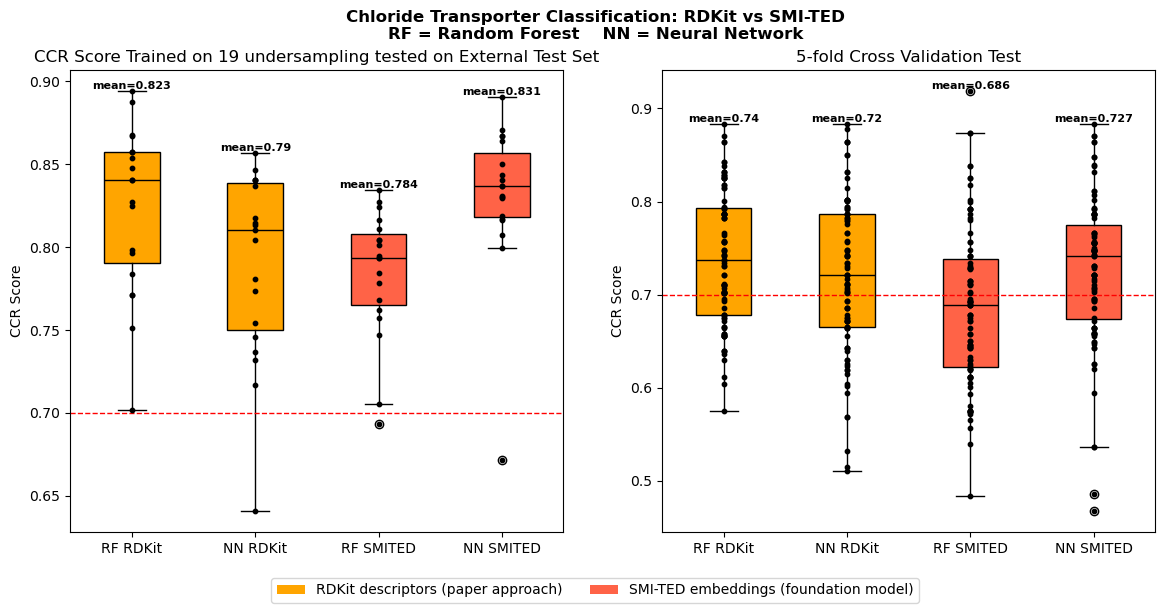

In [113]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np 

# CCR Score 
fig, ax = plt.subplots(1,2, figsize=(14,6))
ax[0].set_ylabel ('CCR Score')
ax[0].set_title('CCR Score Trained on 19 undersampling tested on External Test Set')

ccr_data = [rf_rdkit_ccr,nn_rdkit_ccr,rf_smited_ccr,nn_smited_ccr]
ccr_label = ['RF RDKit','NN RDKit','RF SMITED','NN SMITED']
colors = ['orange', 'orange','tomato','tomato']


ccr_graph = ax[0].boxplot(ccr_data, patch_artist=True, tick_labels= ccr_label, medianprops=dict(color='black'))
for patch, color in zip(ccr_graph['boxes'], colors):
    patch.set_facecolor(color)
for i, values in enumerate (ccr_data):
    x = [i+1]*len(values)
    ax[0].scatter(x,values,color="black",s=10,zorder=3)
ax[0].axhline(0.7, color="red", linestyle="--",
              linewidth=1, label="CCR = 0.7 threshold")
for i, values in enumerate(ccr_data):
    mean = round(sum(values) / len(values), 3)
    max_val = max(values)         
    ax[0].text(
        i + 1,
        max_val,           
        f"mean={mean}",              
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black"
    )            

# Cross validation
ax[1].set_ylabel('CCR Score')
ax[1].set_title ('5-fold Cross Validation Test')

cv_data = [rf_rdkit_cv_ccr,nn_rdkit_cv_ccr,rf_smited_cv_ccr,nn_smited_cv_ccr]
cv_graph =ax[1].boxplot(cv_data,patch_artist=True, tick_labels= ccr_label, medianprops=dict(color='black'))
for patch, color in zip(cv_graph['boxes'], colors):
    patch.set_facecolor(color)
for i, values in enumerate (cv_data):
    x = [i+1]*len(values)
    ax[1].scatter(x,values,color="black",s=10,zorder=3)
ax[1].axhline(0.7, color="red", linestyle="--",
              linewidth=1, label="CCR = 0.7 threshold")
for i, values in enumerate(cv_data):
    mean = round(sum(values) / len(values), 3)
    max_val = max(values)         
    ax[1].text(
        i + 1,
        max_val,           
        f"mean={mean}",              
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black"
    )            

# Graph annotation 
fig.suptitle(
    "Chloride Transporter Classification: RDKit vs SMI-TED\n"
    "RF = Random Forest    NN = Neural Network",
    fontweight="bold"
)
rdkit_patch  = mpatches.Patch(facecolor="orange",
                               label="RDKit descriptors (paper approach)")
smited_patch = mpatches.Patch(facecolor="tomato",
                               label="SMI-TED embeddings (foundation model)")

fig.legend(handles=[rdkit_patch, smited_patch],
           loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

# Save figure to result folder
import os
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/main_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
